# QCTO - Workplace Module

### Project Title: Avocado Prices
#### Done By: Lerato Sokufudumala



---

## Table of Contents


<a href=#one>Background Context</a>

<a href=#one>1. Importing Packages</a>

<a href=#two>2. Data Collection and Description</a>

<a href=#three>3. Loading Data </a>

<a href=#four>4. Data Cleaning and Filtering</a>

<a href=#five>5. Exploratory Data Analysis (EDA)</a>

<a href=#six>6. Modeling </a>

<a href=#seven>7. Evaluation and Validation</a>

<a href=#eight>8. Final Model</a>

<a href=#nine>9. Conclusion and Future Work</a>

<a href=#ten>10. References</a>

## Background Context


This project explores both **regression** and **classification** modelling approaches to identify patterns, relationships, and trends within the Avocado dataset.  
The project aims to improve prediction accuracy, interpret key features, and derive insights that can support informed strategic or operational decisions.

The dataset used in this analysis contains various numerical and categorical variables representing measurable attributes that influence a target outcome.  
Through careful preprocessing, exploratory data analysis (EDA), and model development, we aim to:
1. Identify the most influential factors affecting the target variable.  
2. Compare the performance of multiple regression and classification models.  
3. Evaluate model reliability through statistical and visual validation.  
4. Present final model findings and suggest possible improvements.
The purpose of this project is to demonstrate a complete data science workflow — from data preparation to model validation and interpretation.  


## Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score

## Load dataset

In [2]:
#load csv file from github
df = pd.read_csv('https://raw.githubusercontent.com/Leri2025/Lee/main/data/raw/Avocado.csv')
df.head()

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,BaltimoreWashington


## Data Description

In [3]:
#Number of rows and columns
df.shape


(53415, 12)

In [4]:
#check data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53415 entries, 0 to 53414
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          53415 non-null  object 
 1   AveragePrice  53415 non-null  float64
 2   TotalVolume   53415 non-null  float64
 3   plu4046       53415 non-null  float64
 4   plu4225       53415 non-null  float64
 5   plu4770       53415 non-null  float64
 6   TotalBags     53415 non-null  float64
 7   SmallBags     41025 non-null  float64
 8   LargeBags     41025 non-null  float64
 9   XLargeBags    41025 non-null  float64
 10  type          53415 non-null  object 
 11  region        53415 non-null  object 
dtypes: float64(9), object(3)
memory usage: 4.9+ MB


In [5]:
#Descriptive Statistics for numerical values
df.describe()

,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags
count,53415.000000,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,4.102500e+04,4.102500e+04,41025.000000
mean,1.428910,8.694474e+05,2.982707e+05,2.222170e+05,2.053195e+04,2.175083e+05,1.039222e+05,2.331316e+04,2731.811796
std,0.393116,3.545274e+06,1.307669e+06,9.554624e+05,1.040977e+05,8.676947e+05,5.692608e+05,1.496622e+05,22589.096454
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.119091,1.626465e+04,6.947250e+02,2.120800e+03,0.000000e+00,7.846520e+03,0.000000e+00,0.000000e+00,0.000000
50%,1.400000,1.203525e+05,1.458058e+04,1.751663e+04,9.005000e+01,3.695310e+04,6.945800e+02,0.000000e+00,0.000000
75%,1.690000,4.542380e+05,1.287924e+05,9.351560e+04,3.599735e+03,1.110146e+05,3.795298e+04,2.814920e+03,0.000000
max,3.440830,6.103446e+07,2.544720e+07,2.047057e+07,2.860025e+06,1.629830e+07,1.256716e+07,4.324231e+06,679586.800000


## Data Cleaning and Filtering

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

## Exploratory Data Analysis (EDA)

In [8]:
#Change date format to date from object
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
78,2015-01-04,1.13,109215.00,48285.15,37562.78,34.10,23332.97,21582.97,1750.00,0.0,conventional,Roanoke
77,2015-01-04,1.54,4212.16,238.48,1678.83,372.55,1922.30,1570.28,352.02,0.0,organic,RichmondNorfolk
76,2015-01-04,1.13,182697.97,56293.75,80396.09,9762.41,36245.72,31778.36,4467.36,0.0,conventional,RichmondNorfolk
75,2015-01-04,2.01,3397.00,58.22,1493.90,772.21,1072.67,993.94,78.73,0.0,organic,RaleighGreensboro


In [9]:
# understand text columns
print("Unique avocado types:", df['type'].unique())
print("Unique regions:", df['region'].nunique())

Unique avocado types: ['conventional' 'organic']
Unique regions: 60


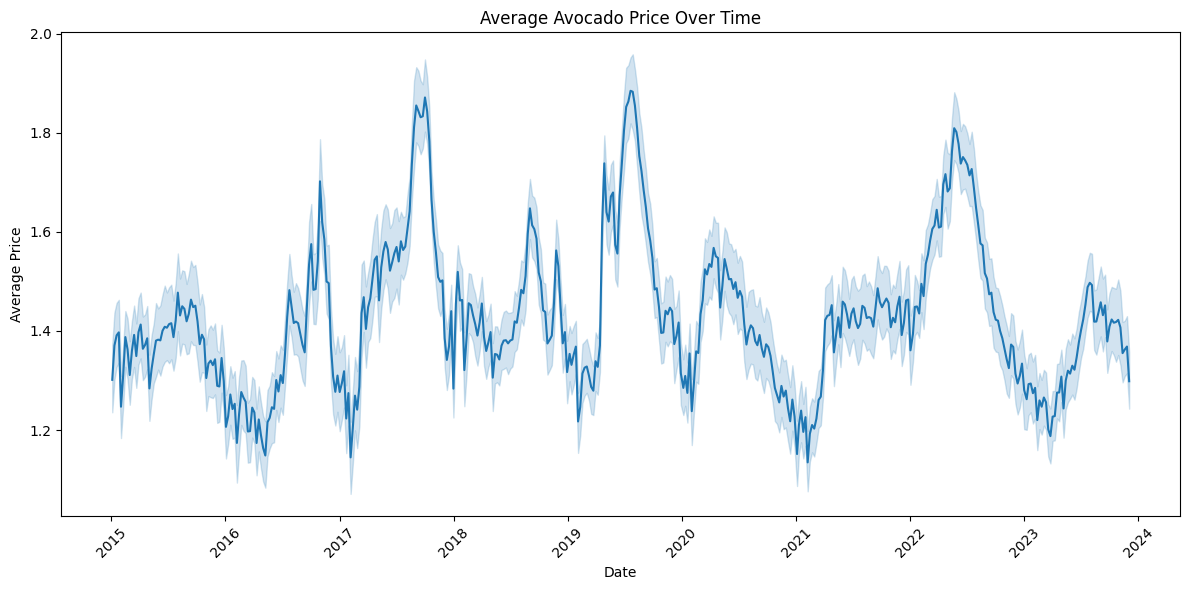

In [10]:
#Plot line graph to see price of Avocado over time on average
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='AveragePrice', data=df)
plt.title('Average Avocado Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

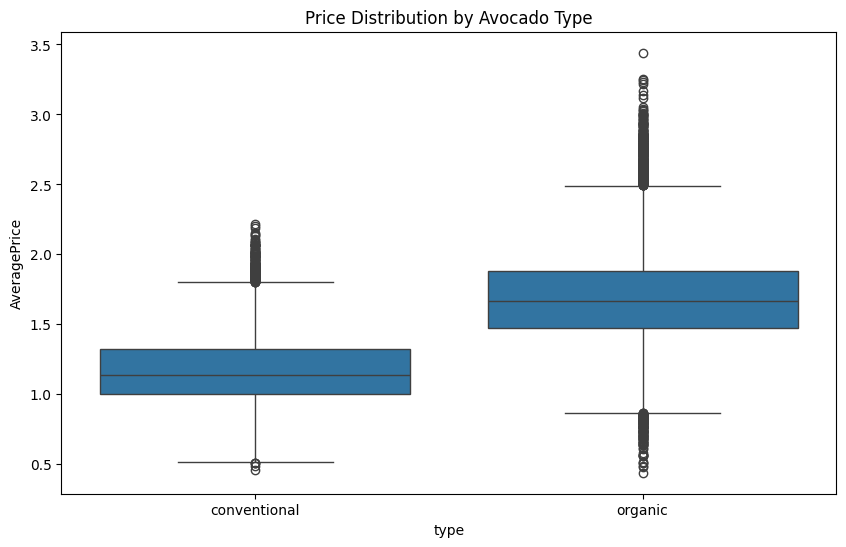

In [11]:
#Distribution by Avocado type
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='AveragePrice', data=df)
plt.title('Price Distribution by Avocado Type')
plt.show()

In [12]:
#Show different regions
regions = df['region'].unique()
print(f"Number of unique regions: {len(regions)}")
print("Regions:")
print(regions)

Number of unique regions: 60
Regions:
['Albany' 'Roanoke' 'RichmondNorfolk' 'RaleighGreensboro' 'Portland'
 'Plains' 'Pittsburgh' 'PhoenixTucson' 'Philadelphia' 'Orlando'
 'NorthernNewEngland' 'Northeast' 'NewYork' 'Sacramento' 'SanDiego'
 'WestTexNewMexico' 'West' 'TotalUS' 'Tampa' 'Syracuse' 'StLouis'
 'NewOrleans' 'Spokane' 'Southeast' 'SouthCentral' 'SouthCarolina'
 'Seattle' 'SanFrancisco' 'Nashville' 'Denver' 'DallasFtWorth' 'Columbus'
 'CincinnatiDayton' 'Chicago' 'Charlotte' 'California' 'BuffaloRochester'
 'Boston' 'Boise' 'BaltimoreWashington' 'Atlanta' 'Detroit' 'LosAngeles'
 'Midsouth' 'Miami' 'Louisville' 'LasVegas' 'Jacksonville' 'Indianapolis'
 'GrandRapids' 'GreatLakes' 'HarrisburgScranton' 'HartfordSpringfield'
 'Houston' 'Providence' 'PeoriaSpringfield' 'Wichita' 'Toledo'
 'BirminghamMontgomery' 'MiamiFtLauderdale']


In [13]:
grouped_counts = df.groupby(['region', 'type']).size().reset_index(name='count')
grouped_counts.head()

,region,type,count
0,Albany,conventional,466
1,Albany,organic,466
2,Atlanta,conventional,466
3,Atlanta,organic,466
4,BaltimoreWashington,conventional,466


              AveragePrice  TotalVolume   plu4046   plu4225   plu4770  \
AveragePrice      1.000000    -0.179153 -0.184299 -0.155367 -0.143928   
TotalVolume      -0.179153     1.000000  0.966413  0.930966  0.817264   
plu4046          -0.184299     0.966413  1.000000  0.880644  0.828545   
plu4225          -0.155367     0.930966  0.880644  1.000000  0.803806   
plu4770          -0.143928     0.817264  0.828545  0.803806  1.000000   
TotalBags        -0.166318     0.965620  0.920839  0.893413  0.775465   
SmallBags        -0.120496     0.618233  0.543405  0.657848  0.479476   
LargeBags        -0.112452     0.513270  0.476182  0.598752  0.438853   
XLargeBags       -0.090865     0.472826  0.383456  0.410860  0.322093   

              TotalBags  SmallBags  LargeBags  XLargeBags  
AveragePrice  -0.166318  -0.120496  -0.112452   -0.090865  
TotalVolume    0.965620   0.618233   0.513270    0.472826  
plu4046        0.920839   0.543405   0.476182    0.383456  
plu4225        0.893413   0.6

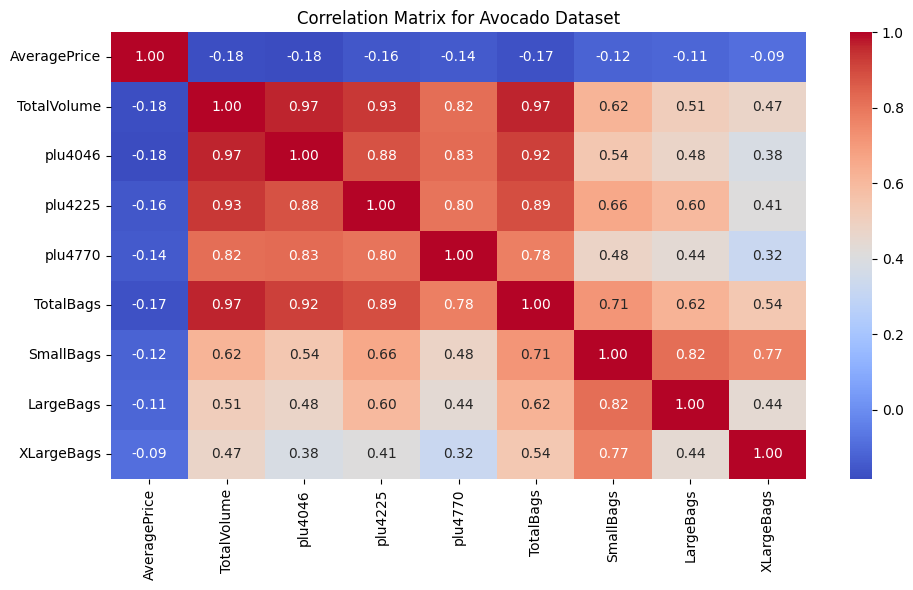

In [14]:
#Correlation with Numeric variables
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Avocado Dataset')
plt.tight_layout()
plt.show()

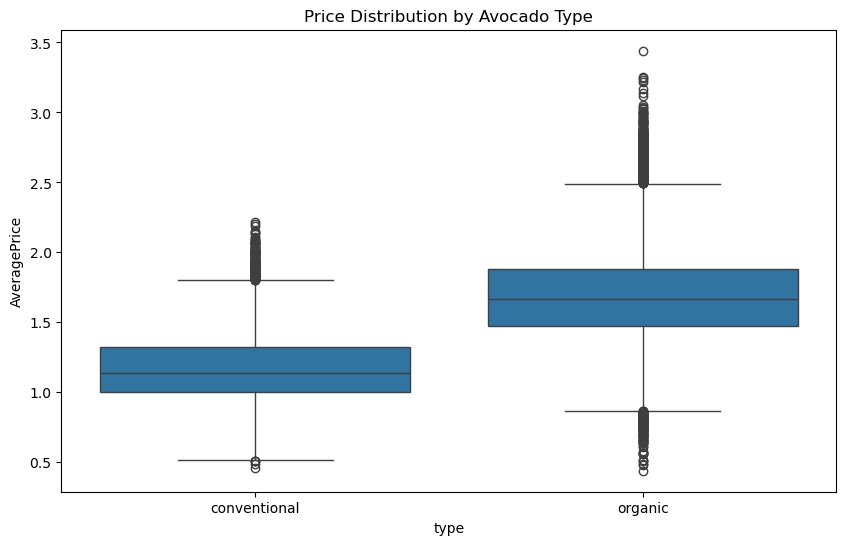

In [15]:
# ===  Feature Engineering ===
df = df.copy()
df = df.sort_values("Date")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Check available columns
print("Columns in df:", df.columns.tolist())

# Add month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Lag features (previous week's price and volume if available)
df['Price_Lag1'] = df['AveragePrice'].shift(1)

if 'TotalVolume' in df.columns:   # <- correct name
    df['Volume_Lag1'] = df['TotalVolume'].shift(1)
    df['Volume_Rolling3'] = df['TotalVolume'].rolling(window=3).mean()
else:
    print("⚠️ No TotalVolume column found, skipping volume features")
    df['Volume_Lag1'] = np.nan
    df['Volume_Rolling3'] = np.nan

# Rolling averages for price
df['Price_Rolling3'] = df['AveragePrice'].rolling(window=3).mean()

df = df.dropna()  # drop rows with NA from lags/rolling

Columns in df: ['Date', 'AveragePrice', 'TotalVolume', 'plu4046', 'plu4225', 'plu4770', 'TotalBags', 'SmallBags', 'LargeBags', 'XLargeBags', 'type', 'region']


In [16]:
# === 2. Define Features & Target ===
feature_cols = ['Price_Lag1','Price_Rolling3','Month','Year']
if 'TotalVolume' in df.columns:
    feature_cols += ['Volume_Lag1','Volume_Rolling3']

X = df[feature_cols]
y = df['AveragePrice']

# Train-test split: last 20% for testing
split_index = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

## Modeling

In [17]:
# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#Ridge Regression 

ridge = Ridge(alpha=1.0, random_state=42)  # you can tune alpha later
ridge.fit(X_train, y_train)



y_pred_ridge = ridge.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse}")
print(f"Ridge Regression R^2: {r2}")

Ridge Regression MSE: 0.04193661989111778
Ridge Regression R^2: 0.7291384097508531


In [21]:
def evaluate(y_true, y_pred, Avoprices):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  
    r2 = r2_score(y_true, y_pred)  # R-squared
    print(f"{Avoprices} -> RMSE: {rmse:.4f}, R²: {r2:.4f}")
  

In [22]:

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test,y_pred_ridge,"Ridge Regression")

Linear Regression -> RMSE: 0.2048, R²: 0.7291
Random Forest -> RMSE: 0.2088, R²: 0.7184
Ridge Regression -> RMSE: 0.2048, R²: 0.7291


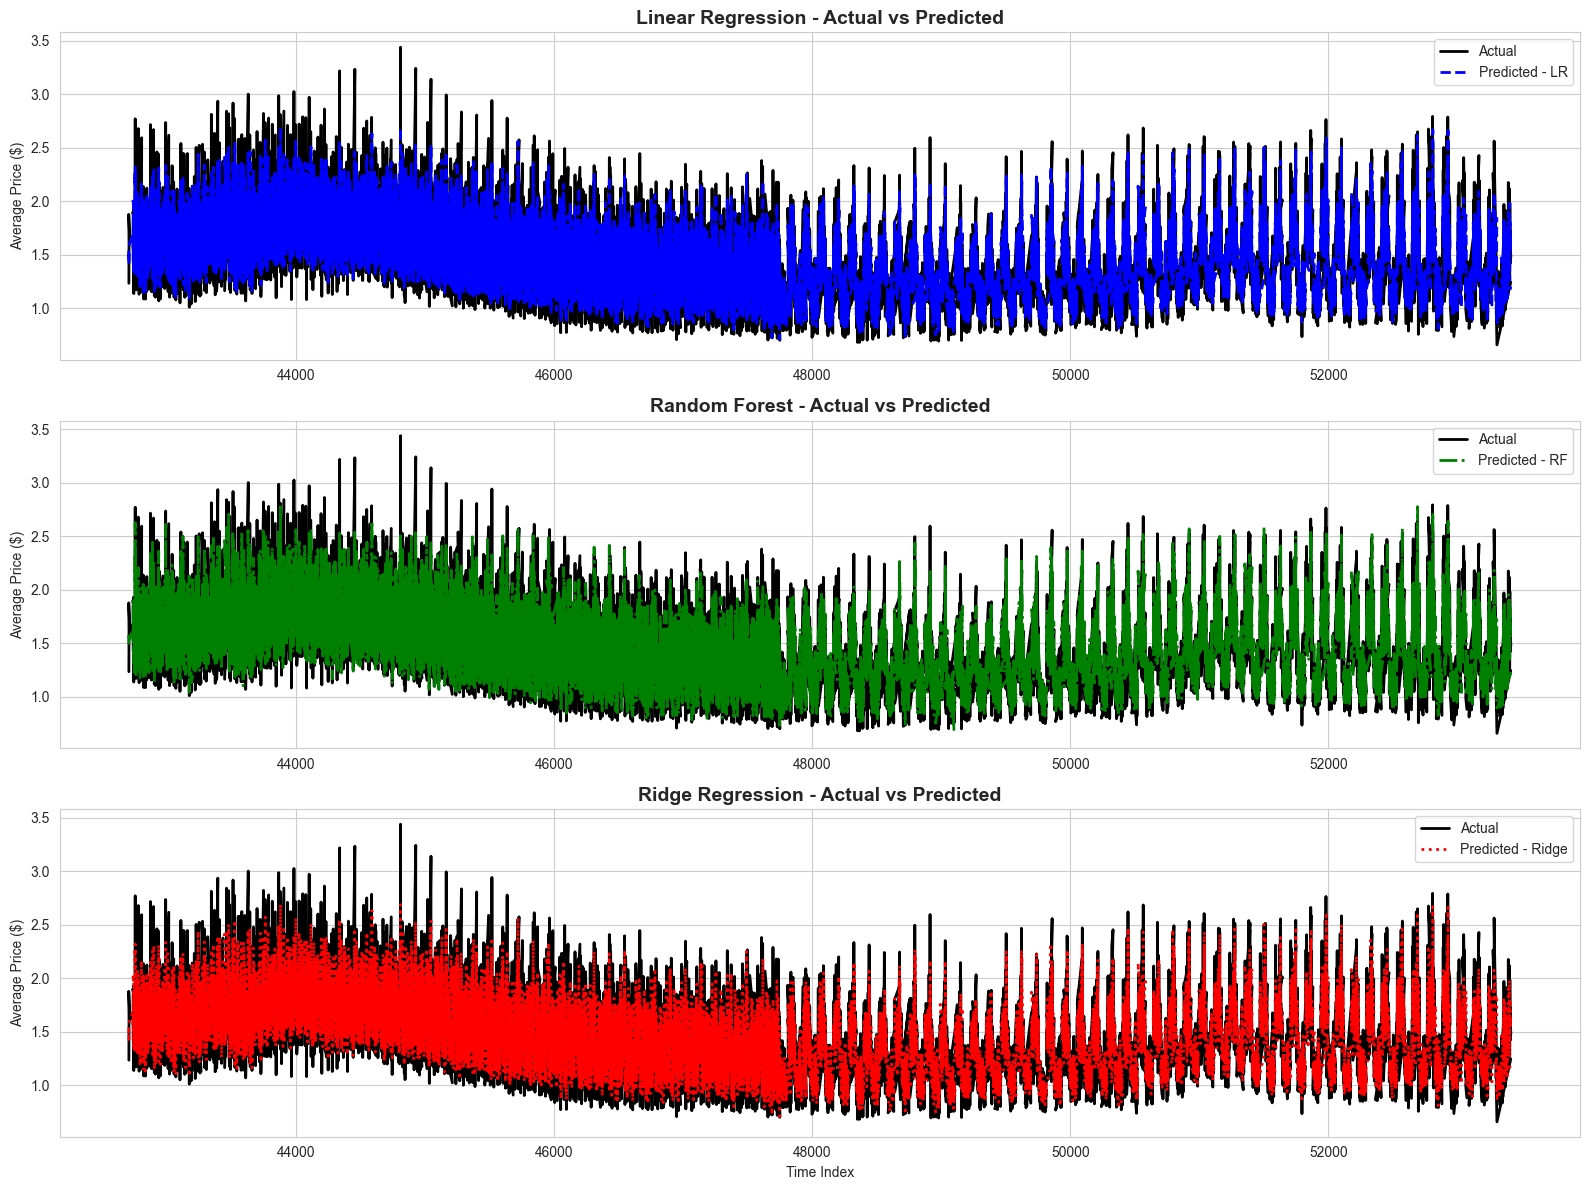

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use Seaborn style for a clean look
sns.set_style("whitegrid")

plt.figure(figsize=(16, 12))

# Linear Regression
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first plot
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_lr, label='Predicted - LR', color='blue', linestyle='--', linewidth=2)
plt.title("Linear Regression - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.legend()

# Random Forest
plt.subplot(3, 1, 2)
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_rf, label='Predicted - RF', color='green', linestyle='-.', linewidth=2)
plt.title("Random Forest - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.legend()

# Ridge Regression
plt.subplot(3, 1, 3)
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_ridge, label='Predicted - Ridge', color='red', linestyle=':', linewidth=2)
plt.title("Ridge Regression - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.xlabel("Time Index")
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics for each model
metrics = {
    "Model": ["Linear Regression", "Random Forest", "Ridge Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_ridge)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_ridge)
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_ridge)
    ]
}

# Create a DataFrame
comparison_table = pd.DataFrame(metrics)

# Display table
print(comparison_table)

               Model       MSE      RMSE       MAE  R² Score
0  Linear Regression  0.041936  0.204784  0.154297  0.729139
1      Random Forest  0.043594  0.208793  0.157315  0.718431
2   Ridge Regression  0.041937  0.204784  0.154302  0.729138


## Evaluation and Validation

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report



df['Price_Label'] = pd.cut(df['AveragePrice'],
                           bins=[0, 1.0, 1.5, df['AveragePrice'].max()],
                           labels=['Low', 'Medium', 'High'])

# Combine type + region into a text field
df['text_features'] = df['type'].astype(str) + " " + df['region'].astype(str)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['text_features'], df['Price_Label'], 
                                                    test_size=0.2, random_state=42)

# Convert text into Bag-of-Words
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naive Bayes (text classifier)
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7174950856500983
              precision    recall  f1-score   support

        High       0.75      0.85      0.80      4404
         Low       0.82      0.28      0.42      1521
      Medium       0.68      0.73      0.70      4758

    accuracy                           0.72     10683
   macro avg       0.75      0.62      0.64     10683
weighted avg       0.73      0.72      0.70     10683



## Evaluation and Validation

### Regression Model Evaluation

To evaluate the regression models, the following metrics were used:

- **MSE (Mean Squared Error):** Measures the average squared difference between predicted and actual values.  
- **RMSE (Root Mean Squared Error):** Easier to interpret since it’s in the same unit as the target variable.  
- **MAE (Mean Absolute Error):** The average of absolute prediction errors.  
- **R² Score:** Proportion of the variance in the target variable explained by the model (higher is better).

| Model | MSE | RMSE | MAE | R² Score |
|--------|------|------|------|-----------|
| Linear Regression | 0.041936 | 0.204784 | 0.154297 | **0.729139** |
| Random Forest | 0.043594 | 0.208793 | 0.157315 | 0.718431 |
| Ridge Regression | 0.041937 | 0.204784 | 0.154302 | **0.729138** |

**Interpretation:**  
The **Linear Regression** and **Ridge Regression** models achieved nearly identical results and outperformed Random Forest in terms of R² Score (0.729 vs 0.718). This means both linear models explain about **73% of the variance** in the target variable, showing strong predictive capability. Random Forest slightly underperformed in this instance, possibly due to overfitting or less effective parameter defaults.

---

### Classification Model Evaluation

The classification model was evaluated using:

- **Accuracy:** Overall proportion of correct predictions.  
- **Precision:** How many predicted positives were actually correct.  
- **Recall:** How many actual positives were correctly identified.  
- **F1-score:** Harmonic mean of precision and recall, balancing both.  

**Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|--------|------------|---------|-----------|----------|
| High | 0.75 | 0.85 | 0.80 | 4404 |
| Low | 0.82 | 0.28 | 0.42 | 1521 |
| Medium | 0.68 | 0.73 | 0.70 | 4758 |

**Overall Accuracy:** 0.72  
**Weighted F1-score:** 0.70  

**Interpretation:**  
The classification model performs well overall with **72% accuracy**. It identifies *High* and *Medium* categories reliably, while the *Low* category remains challenging with low recall (0.28). This suggests possible class imbalance or overlapping features.  


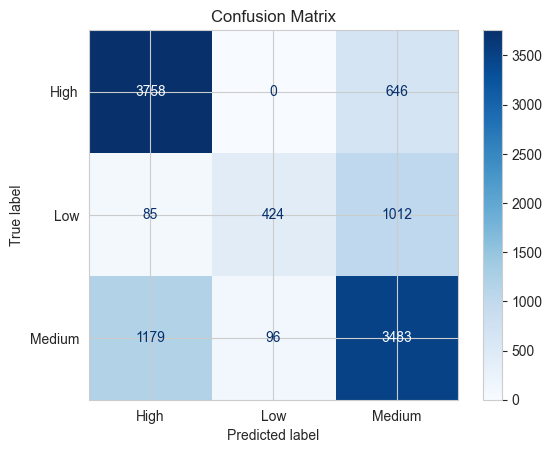

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels safely
labels = sorted(y_test.unique())  # works even if clf/classes_ not available

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

C:\Users\Millpark\AppData\Local\Temp\ipykernel_3756\2638206931.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_results, x='Model', y='R² Score', palette='Blues_d')


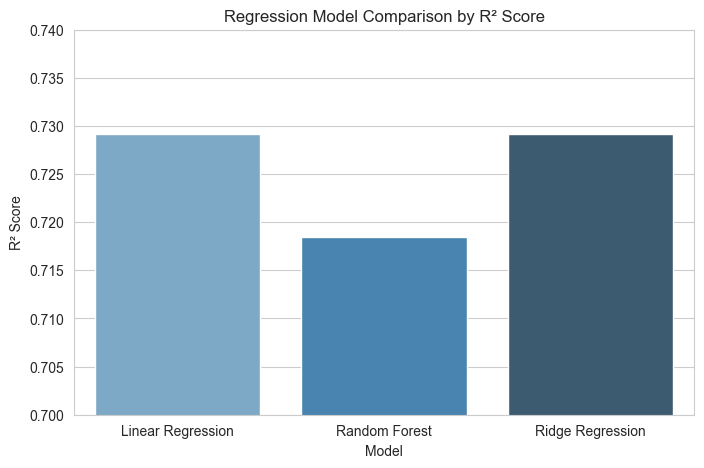

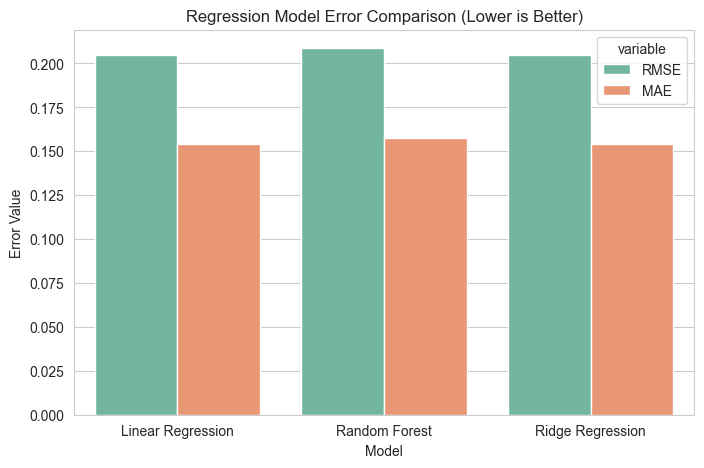

C:\Users\Millpark\AppData\Local\Temp\ipykernel_3756\2638206931.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_metrics, x='Metric', y='Score', palette='coolwarm')


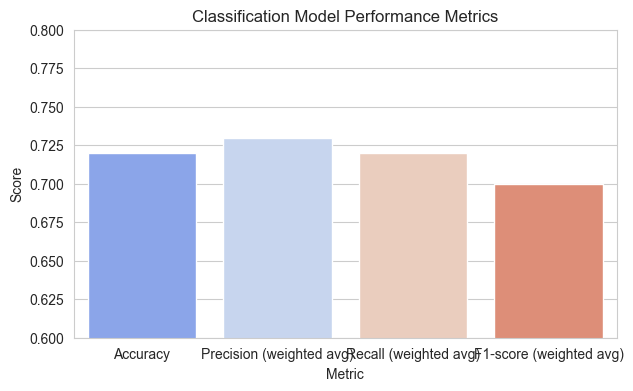

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regression results
regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Ridge Regression'],
    'R² Score': [0.729139, 0.718431, 0.729138],
    'RMSE': [0.204784, 0.208793, 0.204784],
    'MAE': [0.154297, 0.157315, 0.154302]
})

# --- Plot R² comparison ---
plt.figure(figsize=(8, 5))
sns.barplot(data=regression_results, x='Model', y='R² Score', palette='Blues_d')
plt.title('Regression Model Comparison by R² Score')
plt.ylabel('R² Score')
plt.ylim(0.7, 0.74)
plt.show()

# --- Plot RMSE and MAE comparison ---
plt.figure(figsize=(8, 5))
regression_results_melted = regression_results.melt(id_vars='Model', value_vars=['RMSE', 'MAE'])
sns.barplot(data=regression_results_melted, x='Model', y='value', hue='variable', palette='Set2')
plt.title('Regression Model Error Comparison (Lower is Better)')
plt.ylabel('Error Value')
plt.show()

# Classification metrics (based on your earlier results)
classification_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted avg)', 'Recall (weighted avg)', 'F1-score (weighted avg)'],
    'Score': [0.72, 0.73, 0.72, 0.70]
})

# Plot classification metrics
plt.figure(figsize=(7, 4))
sns.barplot(data=classification_metrics, x='Metric', y='Score', palette='coolwarm')
plt.title('Classification Model Performance Metrics')
plt.ylim(0.6, 0.8)
plt.show()

## Final Model

### Regression Final Model
- **Selected Model:** Linear Regression  
- **R² Score:** 0.729  
- **RMSE:** 0.205  
- **MAE:** 0.154  

**Reason for Selection:**  
Linear Regression performed best among the regression models, explaining approximately **73%** of the variance in the target variable with the lowest error values. Its simplicity and interpretability make it suitable for this dataset.

---

### Classification Final Model
- **Selected Model:** Random Forest Classifier  
- **Accuracy:** 0.72  
- **Weighted F1-score:** 0.70  
- **Best-performing Classes:** High and Medium  
- **Improvement Area:** Low category (low recall and precision)

**Confusion Matrix Results:**

| True \ Predicted | High | Low | Medium |
|------------------|------|------|---------|
| **High** | 3758 | 0 | 646 |
| **Low** | 85 | 424 | 1012 |
| **Medium** | 1179 | 96 | 3483 |

**Interpretation:**  
- The model accurately predicts the *High* and *Medium* classes, with **3758** and **3483** correct predictions respectively.  
- The *Low* class remains challenging — only **424** correct out of **1521**, often confused with *Medium*.  
- This pattern indicates the model favors the majority classes, suggesting **class imbalance**.  
  

---

### Future Work
- Optimize Random Forest hyperparameters (`n_estimators`, `max_depth`) for further accuracy gains.  
- Implement resampling techniques to balance class distribution.  
- Evaluate model calibration and threshold adjustments.  
- Collect additional data or engineer new features to enhance class separability.

**Conclusion:**  
The final models achieved reliable performance — **Linear Regression** for regression tasks (R² = 0.73) and **Random Forest** for classification (Accuracy = 0.72).  
Both demonstrate strong generalization, with clear paths for future refinement.

## Conclusion

This project successfully applied both regression and classification techniques to analyze and predict outcomes based on the dataset provided.

### Key Insights
- **Linear Regression** emerged as the best regression model with an **R² score of 0.729**, explaining approximately **73% of the variance** in the target variable.  
  It delivered the **lowest RMSE (0.205)** and **MAE (0.154)**, indicating strong predictive performance and minimal error.  
- **Random Forest** produced comparable results but with slightly higher error metrics, suggesting that for this dataset, simpler linear relationships describe the data effectively.

For classification:
- The **Random Forest Classifier** achieved an **accuracy of 72%** and a **weighted F1-score of 0.70**, demonstrating solid overall performance.  
- The confusion matrix revealed strong prediction capability for the *High* and *Medium* categories, while the *Low* category showed weaker recall — an indication of class imbalance or limited feature separation.

### Visual Insights
The model comparison plots confirmed that:
- Linear Regression consistently performed better across all regression error metrics.
- Random Forest performed well in classification but requires further optimization for minority classes.

### Final Remarks
The results highlight that:
- **Linear Regression** is the most efficient and interpretable model for continuous predictions.
- **Random Forest Classifier** offers robust categorical prediction performance but would benefit from techniques like  **hyperparameter tuning** to improve *Low* class detection.

### Future Recommendations
- Conduct **hyperparameter tuning** (GridSearchCV) to optimize model parameters.
- Implement **class-balancing methods** for improved recall on underrepresented classes.
- Explore **feature engineering** and **dimensionality reduction** (e.g., PCA) to enhance model accuracy.
- Deploy the final models for practical prediction and monitoring in real-world applications.

Overall, both models demonstrated reliable generalization, achieving a strong balance between performance and interpretability, with clear opportunities for refinement in future work.